In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

In [2]:
skyfrac = np.load('skyfracs_szifi_cosmology.npy')          # shape (768,)
sigma_dict = np.load('sigma_dict_szifi.npy', allow_pickle=True).item()  # dict

print('skyfrac shape :', skyfrac.shape)
print('sigma_dict keys:', list(sigma_dict.keys()))
# ------------------------------------------------------------
# theta grid (same for every tile)
# ------------------------------------------------------------
theta_amin = np.exp(np.linspace(np.log(0.5), np.log(32.), 25))  # arcmin
print('θ₅₀₀ grid (arcmin):', theta_amin.round(2))

skyfrac shape : (768,)
sigma_dict keys: ['immf6', 'immf6_noit', 'scimmf6', 'scimmf6_noit', 'scimmf6_beta', 'scimmf6_beta_noit', 'scimmf6_betaT', 'scimmf6_betaT_noit', 'immf5', 'immf5_noit', 'scimmf5', 'scimmf5_noit', 'scimmf5_beta', 'scimmf5_beta_noit', 'scimmf5_betaT', 'scimmf5_betaT_noit', 'immf4', 'immf4_noit', 'scimmf4', 'scimmf4_noit']
θ₅₀₀ grid (arcmin): [ 0.5   0.59  0.71  0.84  1.    1.19  1.41  1.68  2.    2.38  2.83  3.36
  4.    4.76  5.66  6.73  8.    9.51 11.31 13.45 16.   19.03 22.63 26.91
 32.  ]


In [3]:
# skyfrac

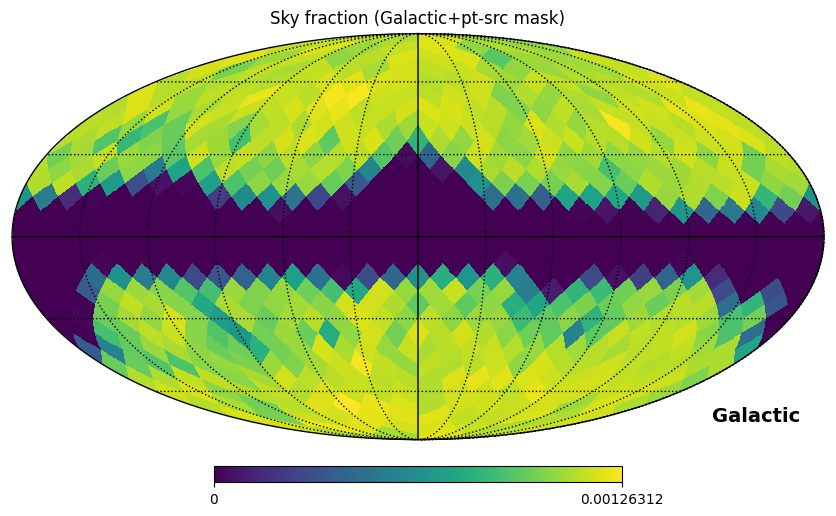

In [4]:
# ================================================================
# Cell 3 – quick look at sky-fraction map
# ================================================================
NSIDE = 8
npix = hp.nside2npix(NSIDE)

# the 768 tiles are simply healpix pixels 0…767
full_map = np.empty(npix)
full_map[:] = np.nan                    # grey outside the tile list
full_map[:len(skyfrac)] = skyfrac       # assign the stored values

hp.mollview(full_map, coord='G', title='Sky fraction (Galactic+pt-src mask)', cmap='viridis')
hp.graticule()

In [5]:
w = skyfrac[:,None]
w.shape

(768, 1)

In [6]:
full_map.min(), full_map.max()

(0.0, 0.001263121763865153)

In [7]:
# ================================================================
# Cell 4 – noise vs θ₅₀₀ for the immf6 filter
# ================================================================
filter_name = 'immf6'          # baseline filter (6 HFI, no deprojection)
sigma_matrix = sigma_dict[filter_name]   # shape (768, 25)
# sigma_matrix

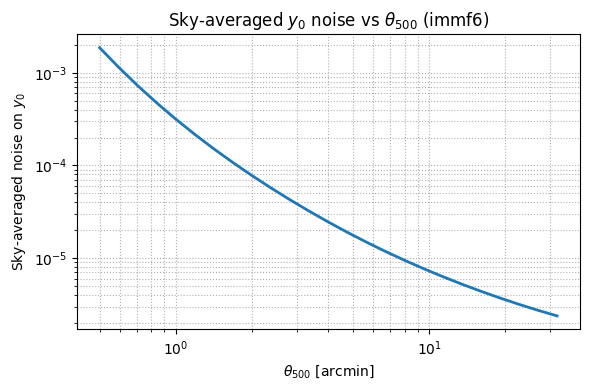

In [8]:
# --- load inputs ---
sigma_obj = np.load("sigma_dict_szifi.npy", allow_pickle=True)
# if isinstance(sigma_obj, np.ndarray) and sigma_obj.dtype == object and sigma_obj.shape == ():
sigma_obj = sigma_obj.item()
# print(sigma_obj)
filter_name = 'immf6'                         # 6 HFI, no deprojection
data = sigma_obj[filter_name]                # dict: {tile_index -> 1D array over theta_500}
skyfr = np.load("skyfracs_szifi_cosmology.npy").ravel()  # length 768

# theta_500 grid (arcmin) — should be length 25
first = next(iter(data.values()))
# print('first:', first)
ntheta = len(first)
# print('ntheta =', ntheta)
theta_grid = np.exp(np.linspace(np.log(0.5), np.log(32.0), ntheta))

# --- sky-fraction–weighted mean noise across tiles (no NaN logic) ---
num = np.zeros(ntheta, dtype=float)
den = 0.0
for tile, arr in data.items():
    w = float(skyfr[int(tile)])
    y = np.asarray(arr, dtype=float)
    num += w * y
    den += w

sigma_skyavg = num / den  # 1D, length ntheta

# --- plot ---
plt.figure(figsize=(6,4))
plt.loglog(theta_grid, sigma_skyavg, lw=2)
plt.xlabel(r'$\theta_{500}$ [arcmin]')
plt.ylabel(r'Sky-averaged noise on $y_0$')
plt.title(f"Sky-averaged $y_0$ noise vs $\\theta_{{500}}$ ({filter_name})")
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()